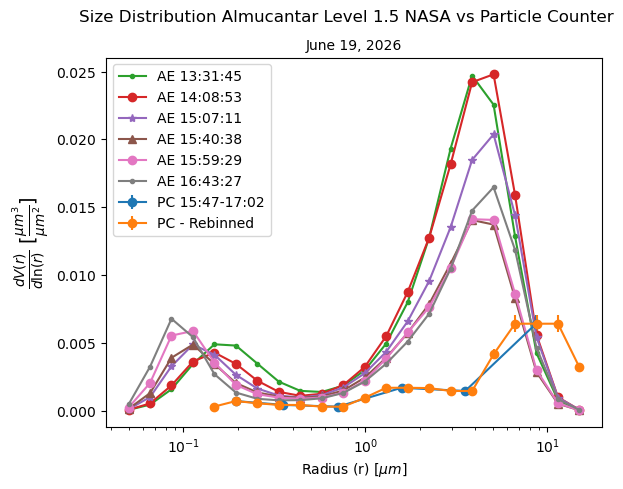

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Functions:
def centers_to_edges_log(x_centers):
    x_centers = np.asarray(x_centers, dtype=float)
    edges = np.zeros(len(x_centers) + 1)
    edges[1:-1] = np.sqrt(x_centers[:-1] * x_centers[1:])
    edges[0] = x_centers[0]**2 / edges[1]
    edges[-1] = x_centers[-1]**2 / edges[-2]
    return edges


def rebin_dVdlnr_log(old_edges, old_dVdlnr, new_edges):
    old_edges = np.asarray(old_edges, dtype=float)
    old_dVdlnr = np.asarray(old_dVdlnr, dtype=float)
    new_edges = np.asarray(new_edges, dtype=float)
    ln_old_edges = np.log(old_edges)
    ln_new_edges = np.log(new_edges)
    new_dVdlnr = np.full(len(new_edges) - 1, np.nan)

    for k in range(len(new_edges) - 1):
        new_low = ln_new_edges[k]
        new_high = ln_new_edges[k + 1]
        new_width = new_high - new_low
        total_volume = 0.0
        overlap_found = False

        for i in range(len(old_dVdlnr)):
            old_low = ln_old_edges[i]
            old_high = ln_old_edges[i + 1]
            overlap_low = max(old_low, new_low)
            overlap_high = min(old_high, new_high)
            overlap_width = overlap_high - overlap_low

            if overlap_width > 0:
                total_volume += old_dVdlnr[i] * overlap_width
                overlap_found = True

        if overlap_found:
            new_dVdlnr[k] = total_volume / new_width

    return new_dVdlnr

def rebin_uncertainty_log(old_edges, old_sigma, new_edges):
    old_edges = np.asarray(old_edges, dtype=float)
    old_sigma = np.asarray(old_sigma, dtype=float)
    new_edges = np.asarray(new_edges, dtype=float)
    ln_old_edges = np.log(old_edges)
    ln_new_edges = np.log(new_edges)
    new_sigma = np.full(len(new_edges) - 1, np.nan)

    for k in range(len(new_edges) - 1):
        new_low = ln_new_edges[k]
        new_high = ln_new_edges[k + 1]
        new_width = new_high - new_low
        sigma2 = 0.0
        overlap_found = False

        for i in range(len(old_sigma)):
            old_low = ln_old_edges[i]
            old_high = ln_old_edges[i + 1]
            overlap_low = max(old_low, new_low)
            overlap_high = min(old_high, new_high)
            overlap_width = overlap_high - overlap_low

            if overlap_width > 0:
                weight = overlap_width / new_width
                sigma2 += (weight * old_sigma[i])**2
                overlap_found = True

        if overlap_found:
            new_sigma[k] = np.sqrt(sigma2)

    return new_sigma

# NASA Aeronet Data:
data = pd.read_csv('20260711_Rexburg_Idaho.csv')

y1 = data.iloc[0,5:27].values
y2 = data.iloc[1,5:27].values
y3 = data.iloc[2,5:27].values
y4 = data.iloc[3,5:27].values
y5 = data.iloc[4,5:27].values
y6 = data.iloc[5,5:27].values

x = data.columns[5:27].astype(float).values

# Particle Counter (PC) Calculation:
particle = pd.read_csv('Particle_Counter_Data_July_11_2026_Flight.csv')
alt = pd.read_csv('AltitudeData07.11(KO6DQM).csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce').dt.floor('min')
alt['Time'] = pd.to_datetime(alt['time'], errors='coerce').dt.floor('min')

start_time = pd.Timestamp('2026-07-11 15:49:00')

particle_strip = particle[(particle['Time']>=start_time) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude_raw'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()

z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

# Calculating Uncertainty
σz = 5.0  # Assuming the altimeter sensor accuracy is about 5m (clarify pending)
particle_rel = 0.1  # 10% Uncertainty from the PC

dV_for_sum = np.column_stack([dVdlnr1[:-1],dVdlnr2[:-1],dVdlnr3[:-1],
                              dVdlnr4[:-1],dVdlnr5[:-1],dVdlnr6[:-1]])

# Particle Counter Uncertainty
σ_py_pc = particle_rel * np.abs(py)

# Altitude dz Uncertainty
σ_z = np.full_like(z,σz,dtype=float)
σ_dz = np.sqrt(σ_z[:-1]**2 + σ_z[1:]**2)
σ_py_alt = np.sqrt(np.sum((dV_for_sum * σ_dz[:,None])**2,axis=0))*1e-12

# Total Uncertainty
σpy = np.sqrt(σ_py_pc**2 + σ_py_alt**2)

# Working on Rebinning
# AERONET radius bin edges from AERONET radius centers
aeronet_r_edges = centers_to_edges_log(x)

# Particle-counter radius edges from your original code
particle_r_edges = r_edges

# Rebin the particle-counter Riemann-sum result
py_rebinned = rebin_dVdlnr_log(old_edges=particle_r_edges,old_dVdlnr=py,new_edges=aeronet_r_edges)

# Rebin the uncertainty
σpy_rebinned = rebin_uncertainty_log(old_edges=particle_r_edges,old_sigma=σpy,new_edges=aeronet_r_edges)

# Plotting the Graph
plt.errorbar(r_mid,py, yerr=σpy,fmt='o-',label='PC 15:47-17:02')
plt.errorbar(x,py_rebinned,yerr=σpy_rebinned,fmt='o-',label='PC - Rebinned')
plt.plot(x, y1, '.-', label="AE 13:31:45")
plt.plot(x, y2, 'o-', label="AE 14:08:53")
plt.plot(x, y3, '*-', label="AE 15:07:11")
plt.plot(x, y4, '^-', label="AE 15:40:38")
plt.plot(x, y5, 'o-', label="AE 15:59:29")
plt.plot(x, y6, '.-', label="AE 16:43:27") 
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 NASA vs Particle Counter')
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()

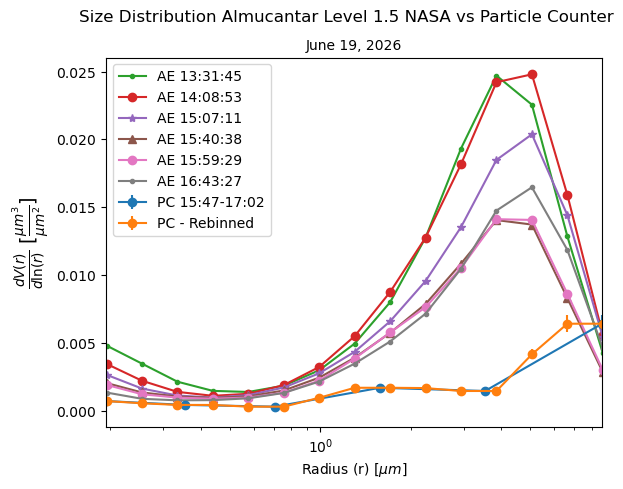

In [5]:
plt.errorbar(r_mid,py, yerr=σpy,fmt='o-',label='PC 15:47-17:02')
plt.errorbar(x,py_rebinned,yerr=σpy_rebinned,fmt='o-',label='PC - Rebinned')
plt.plot(x, y1, '.-', label="AE 13:31:45")
plt.plot(x, y2, 'o-', label="AE 14:08:53")
plt.plot(x, y3, '*-', label="AE 15:07:11")
plt.plot(x, y4, '^-', label="AE 15:40:38")
plt.plot(x, y5, 'o-', label="AE 15:59:29")
plt.plot(x, y6, '.-', label="AE 16:43:27") 
plt.xlim(min(r_mid),max(r_mid))
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 NASA vs Particle Counter')
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()